Valeria Vásquez 20230355 | 
17 de abril del 2026
# Laboratorio 2

## Ejercicio 1
Análisis Exploratorio de Datos (EDA) usando Pandas
* Análisis del tipo de datos que se tiene en el dataset
* Análisis de variables cuantitativas
* Análisis de variables cualitativas

¿Cómo se relaciona este análisis con las metodologías vistas en clase (DLM, DL, CRISP-DM)?
* Se relaciona porque forma parte de la etapa inicial de entender los datos.
* Se conecta con las fases de Data Understanding y Data Preparation, ya que el análisis exploratorio ayuda a decidir cómo preparar los datos para las siguientes etapas.

In [0]:
import pandas

df = spark.table("samples.wanderbricks.employees")
df_pd = df.toPandas()

# Análisis del tipo de datos
print("\nTipos de datos:")
print(df.dtypes)

# Análisis de variables cuantitativas
print("\nResumen estadístico de variables numéricas:")
print(df_pd.describe(include="all"))

# 6. Análisis de variables cualitativas
vars_cualitativas = df_pd.select_dtypes(include=["object", "category", "bool"])

for col in vars_cualitativas.columns:
    print(f"\nVariable cualitativa: {col}")
    print(df_pd[col].value_counts())


Tipos de datos:
[('employee_id', 'bigint'), ('host_id', 'bigint'), ('name', 'string'), ('role', 'string'), ('email', 'string'), ('phone', 'string'), ('country', 'string'), ('joined_at', 'date'), ('end_service_date', 'date'), ('is_currently_employed', 'boolean')]

Resumen estadístico de variables numéricas:
         employee_id       host_id  ... end_service_date is_currently_employed
count   73006.000000  73006.000000  ...            14439                 73006
unique           NaN           NaN  ...              739                     2
top              NaN           NaN  ...       2025-07-30                  True
freq             NaN           NaN  ...              421                 58567
mean    36503.500000   9684.694231  ...              NaN                   NaN
std     21075.161213   5597.845522  ...              NaN                   NaN
min         1.000000      1.000000  ...              NaN                   NaN
25%     18252.250000   4843.000000  ...              NaN   

## Ejercicio 2
Crear gráficos usando paquetes de Python (matplotlib, seaborn, etc)
* Crear un diagrama de dispersión (scatter plot)
* Crear un gráfico de barras (bar plot)
* Crear un histograma (histogram)

¿Cómo se podría identificar el tipo de gráfico ideal para presentar información de un dataset?
* Depende del tipo de variable y del objetivo del análisis. 
* Histograma: distribución de una variable cuantitativa.
* Dispersión: relación entre variables cuantitativas.
* Barras: comprarar categorías. Puede ser utilizado con cualitativas al comparar las frecuencias por ejemplo.
* Pie: proporción entre categorías.

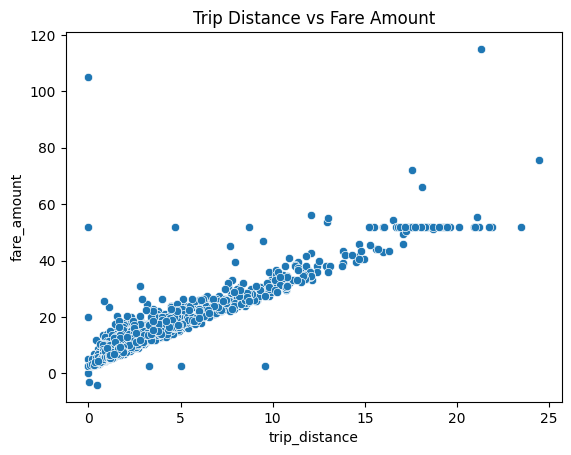

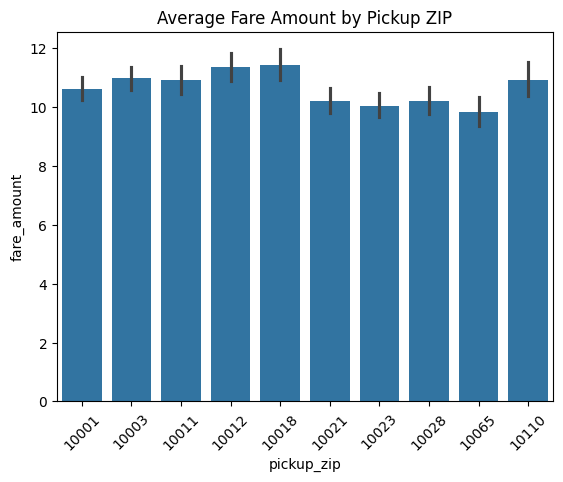

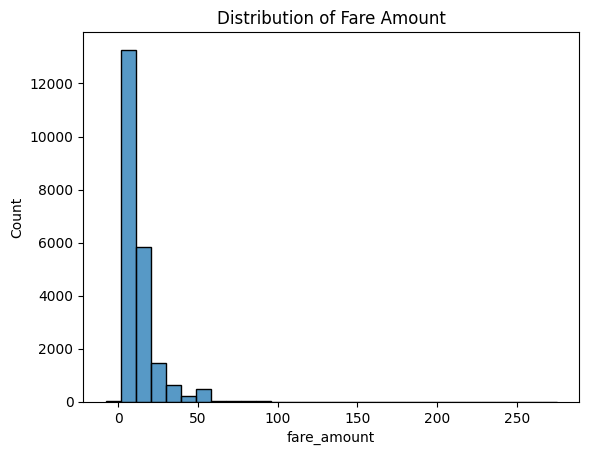

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = spark.table("samples.nyctaxi.trips")
df_pd = df.select("trip_distance", "fare_amount", "pickup_zip").dropna().toPandas()

df_sample = df_pd.sample(3000, random_state=42)

# Scatter plot
sns.scatterplot(data=df_sample, x="trip_distance", y="fare_amount")
plt.title("Trip Distance vs Fare Amount")
plt.show()

# Bar plot
top_zips = df_pd["pickup_zip"].value_counts().head(10).index
df_bar = df_pd[df_pd["pickup_zip"].isin(top_zips)]

sns.barplot(data=df_bar, x="pickup_zip", y="fare_amount")
plt.title("Average Fare Amount by Pickup ZIP")
plt.xticks(rotation=45)
plt.show()

# Histogram
sns.histplot(data=df_pd, x="fare_amount", bins=30)
plt.title("Distribution of Fare Amount")
plt.show()

## Ejercicio 3
Complementar análisis numérico con gráficos en un dataset
* Análisis de variables cuantitativas con su respectivo gráfico (histograma, dispersión)
* Análisis de variables cualitativas con su respectivo gráfico (barras, pieI)

¿Tendría sentido incluir un Análisis Exploratorio de Datos en un pipeline de datos?
* Sí tiene sentido. El EDA permite conocer mejor los datos antes de manipularlos, lo que permite definir métodos a utilizar, variables útiles, etc.

ANALISIS DE VARIABLES CUANTITATIVAS

Resumen estadistico:
       trip_distance   fare_amount
count   21932.000000  21932.000000
mean        2.852829     12.348727
std         3.439954     10.327888
min         0.000000     -8.000000
25%         1.000000      6.500000
50%         1.690000      9.000000
75%         3.080000     14.000000
max        30.600000    275.000000

Promedio de trip_distance: 2.852829199343425
Promedio de fare_amount: 12.348726974284153

Mediana de trip_distance: 1.69
Mediana de fare_amount: 9.0

Minimo de trip_distance: 0.0
Maximo de trip_distance: 30.6

Minimo de fare_amount: -8.0
Maximo de fare_amount: 275.0


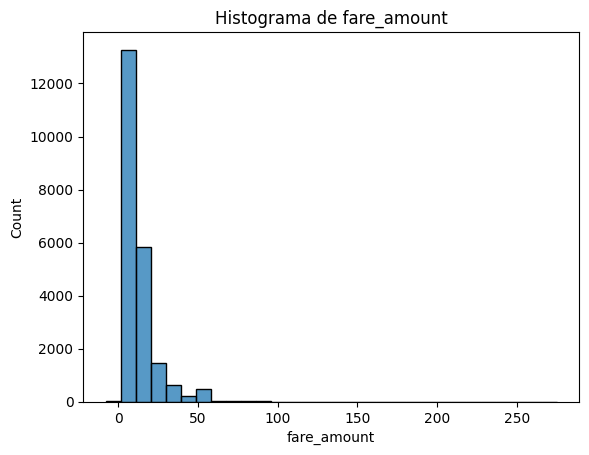

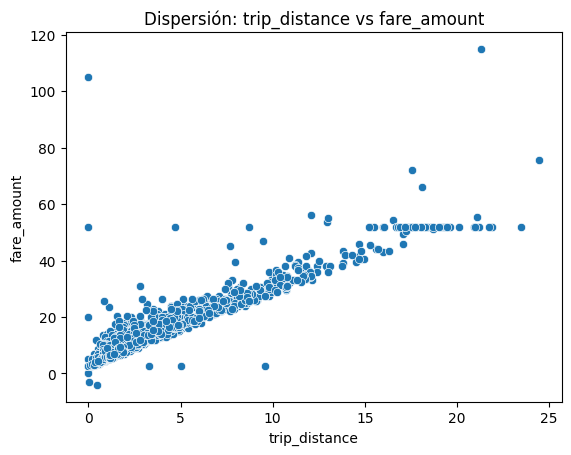


ANALISIS DE VARIABLES CUALITATIVAS

Frecuencias de pickup_zip:
pickup_zip
10001    1227
10003    1181
10011    1129
10021    1021
10018    1012
10023    1008
10028     929
10012     834
10110     763
10065     702
Name: count, dtype: int64


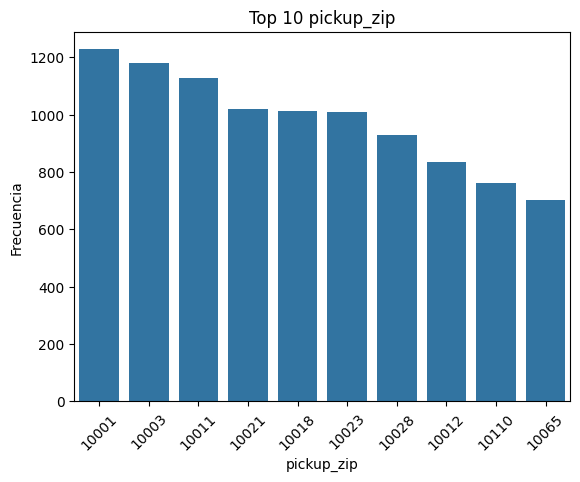

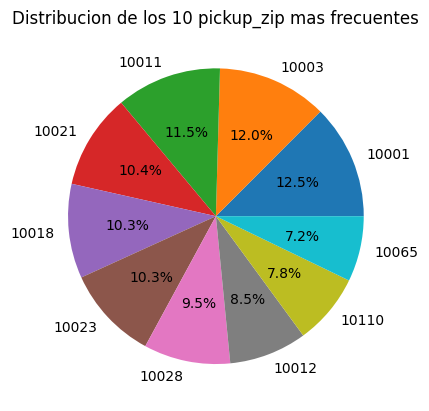

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = spark.table("samples.nyctaxi.trips")
df_pd = df.select("trip_distance", "fare_amount", "pickup_zip").dropna().toPandas()

print("ANALISIS DE VARIABLES CUANTITATIVAS")
print("\nResumen estadistico:")
print(df_pd[["trip_distance", "fare_amount"]].describe())

print("\nPromedio de trip_distance:", df_pd["trip_distance"].mean())
print("Promedio de fare_amount:", df_pd["fare_amount"].mean())

print("\nMediana de trip_distance:", df_pd["trip_distance"].median())
print("Mediana de fare_amount:", df_pd["fare_amount"].median())

print("\nMinimo de trip_distance:", df_pd["trip_distance"].min())
print("Maximo de trip_distance:", df_pd["trip_distance"].max())

print("\nMinimo de fare_amount:", df_pd["fare_amount"].min())
print("Maximo de fare_amount:", df_pd["fare_amount"].max())

sns.histplot(data=df_pd, x="fare_amount", bins=30)
plt.title("Histograma de fare_amount")
plt.show()

muestra = df_pd.sample(3000, random_state=42)

sns.scatterplot(data=muestra, x="trip_distance", y="fare_amount")
plt.title("Dispersión: trip_distance vs fare_amount")
plt.show()


print("\nANALISIS DE VARIABLES CUALITATIVAS")
print("\nFrecuencias de pickup_zip:")
print(df_pd["pickup_zip"].value_counts().head(10))

top_zips = df_pd["pickup_zip"].value_counts().head(10)

sns.barplot(x=top_zips.index.astype(str), y=top_zips.values)
plt.title("Top 10 pickup_zip")
plt.xlabel("pickup_zip")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

plt.pie(top_zips.values, labels=top_zips.index.astype(str), autopct="%1.1f%%")
plt.title("Distribucion de los 10 pickup_zip mas frecuentes")
plt.show()

# Ejercicio 4
Manejo de metadata
* Uso de la línea de comandos para ver metadata
* Uso de Python para extraer metadata de un paquete

¿Cómo beneficiaría un buen manejo de metadata a un pipeline de datos?
* Un buen manejo de metadata mejora la organización, trazabilidad y reproducibilidad del pipeline. 
* La metadata permite saber de dónde vienen los datos, cuándo fueron creados o modificados, qué significan las columnas, qué versión de paquetes se usó cómo se transformó la información, etc. 

In [0]:
%sh
pip show pandas

Name: pandas
Version: 2.2.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License
        
        Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
        All rights reserved.
        
        Copyright (c) 2011-2023, Open source contributors.
        
        Redistribution and use in source and binary forms, with or without
        modification, are permitted provided that the following conditions are met:
        
        * Redistributions of source code must retain the above copyright notice, this
          list of conditions and the following disclaimer.
        
        * Redistributions in binary form must reproduce the above copyright notice,
          this list of conditions and the following disclaimer in the documentation
          and/or other materials 

In [0]:
from importlib.metadata import metadata

meta = metadata("pandas")

print("Name:", meta["Name"])
print("Version:", meta["Version"])
print("Summary:", meta["Summary"])
print("Author:", meta["Author"])
print("License:", meta["License"])
print("Home-page:", meta["Home-page"])

Name: pandas
Version: 2.2.3
Summary: Powerful data structures for data analysis, time series, and statistics
Author: None
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names of its
  contributors may be used to endorse or promote products derived from
  this software without specific prior written perm

/home/spark-249581e9-a2df-4e1a-99c4-c8/.ipykernel/1960/command-7630771024084025-4097593426:8: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  print("Author:", meta["Author"])


# Ejercicio 5
Link de página para Portafolio: [https://valevasqc.github.io/introadatos/](https://valevasqc.github.io/introadatos/)

¿Cuál sería el archivo ideal para mostrar los proyectos en una página de Portafolio?
* `index.html` porque es la convención para el punto de partida de un website.
* Es mejor que un md, por ejemplo, porque permite mayor personalización, además de que es lightweight y fácil de aprender a usar.